---
title: "3D Forward Simulation for Sheet-Like Conductors Part 1"
subtitle: Rectangular (Maxwell) plates
authors:
  - id: devincowan
---

```{admonition} Advanced notebook
:class: danger
This tutorial focusses on advanced functionality within SimPEG. Basic and intermediate level functionality are not discussed in detail, as we assume the user is already an experienced SimPEG user.
```

```{admonition} Medium-weight notebook
:class: caution
Requires moderate computational resources. Run-times may exceed several minutes and require up to 8 GB of available RAM.
```

```{admonition} Prerequisite Tutorials
:class: note
* [Fundamentals of Finite Volume for TDEM Simulations](fwd_tdem_fundamentals.ipynb
* [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb)
```

**Keywords:** Forward simulation, hierarchical finite volume, Maxwell plate, sheet-like conductor.

</br>

**Summary:** This is part 1 of a 2 part tutorial for simulating TDEM data in the presence of sheet-like conductors within a 3D host. Here, we consider the data simulated for a set of rectangular plate conductors (e.g. Maxwell plates). We employ a hierarchical finite volume approach, which parameterizes thick structures as cell conductivities ($\sigma$), sheet-like conductors as face conductances ($\xi_x, \xi_y, \xi_z$), and wire-like conductors as edge integrated conductances ($\lambda_x, \lambda_y, \lambda_z$); see the figure below. Data are simulated for the borehole UTEM survey geometry presented in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial. Functionality used to simulate the data is imported from the [simpeg.electromagnetics.time_domain](xref:simpeg#simpeg.electromagnetics.time_domain) module.

</br>

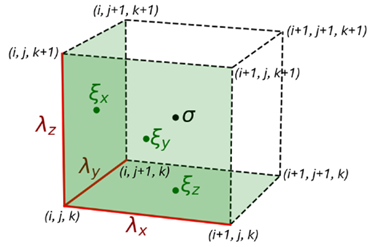

</br>

**Learning Objectives:**

- Introducing the hierarchical simulation class and hierarchical physical properties
- Defining Maxwell plates within the SimPEG framework
- Reading a writing Maxwell PTE files
- Designing appropriates meshes
- Mapping the properties of plate conductors to meshes

## Importing Modules

Here, we import all of the functionality required to run the notebook for the tutorial exercise. All of the functionality specific to TDEM is imported from [simpeg.electromagnetics.time_domain](xref:simpeg#simpeg.electromagnetics.time_domain).
We also import some useful utility functions from [simpeg.utils](xref:simpeg#simpeg.utils).

In [1]:
# SimPEG functionality
import simpeg.electromagnetics.time_domain as tdem
from simpeg import maps
from simpeg.utils import plot2Ddata, get_default_solver

# discretize functionality
from discretize import TreeMesh
from discretize.utils import mkvc, ndgrid, active_from_xyz

# Common Python functionality
import numpy as np
from scipy.interpolate import LinearNDInterpolator
from scipy.constants import mu_0
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

import sys, os
sys.path.append(r"D:\Documents\Python\my_supporting_functions")
from my_plate_utils import (
    MaxwellPlate,
    read_pte_file,
    write_pte_file,
    dipping_plate_to_nodes,
    get_face_indices_plate,
)
from my_waveform_utils import TriangularUTEMWaveform
from my_field_utils import computeH0

mpl.rcParams.update({"font.size": 14})

write_output = False  # Optional

## Defining the Topography

Here, we reuse the valley-like topography from the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial.

In [2]:
# Generate or load topography
x_topo, y_topo = np.meshgrid(
    np.linspace(-2100, 2100, 141), np.linspace(-2100, 2100, 141)
)
z_topo = 300.0 + 100.0 * (1 / np.pi) * (
    np.arctan((x_topo - 500 * np.sin(np.pi * y_topo / 2800) - 1000.0) / 300.0)
    - np.arctan((x_topo - 500 * np.sin(np.pi * y_topo / 2800) + 1000.0) / 300.0)
)

In [3]:
# Turn into a (N, 3) numpy.ndarray
x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)]

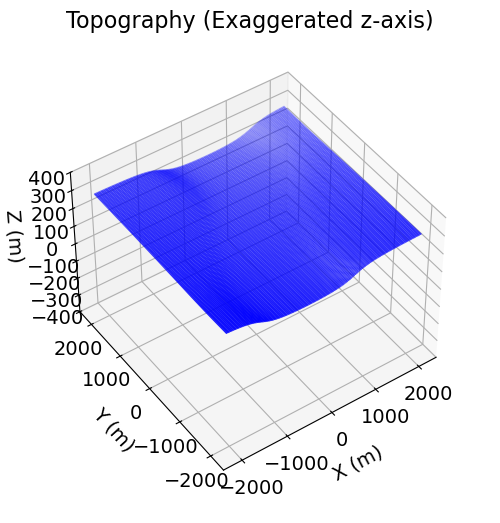

In [4]:
# Plot the topography
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([-400, 400])
ax.scatter3D(topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2], s=0.25, c="b")
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=45.0, azim=-125)

## Defining the (UTEM) Survey

The objects required to define a TDEM survey within SimPEG are discussed in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial.

**For this tutorial**, we simulate borehole University of Toronto electromagnetic (UTEM) data for a single transmitter loop. Some basic information regarding UTEM survey geometry and its data can be found [here](https://giftoolscookbook.readthedocs.io/en/latest/content/comprehensive_workflow/utem/1_basic_anomalies.html). The transmitter loop is square with a side length of 1200 m. The operating frequency of the UTEM waveform is 1 Hz. db/dt sensors are used to measure 3-component data for a highly-regulated triangular waveform with a 100% duty cycle. db/dt sensors are located within a borehole at (x, y) = (80 m, 20 m) that extends 800 m vertically below the Earth's surface.

#### Defining Survey Parameters

In [5]:
# WAVEFORM PROPERTIES
operating_frequency = 1.0  # Operating frequency
I_max = 1.0  # Maximum current amplitude

# TRANSMITTER LOOP PROPERTIES
loop_width = 1200

# RECEIVER LOCATIONS
x_bh, y_bh = 80., 20.           # horizontal position
ds = 25.0                       # receiver spacing
s_max = topo_xyz[:, -1].min()   # top receiver
s_min = s_max - 800.            # bottom receiver

# TIME CHANNELS
period = 1 / operating_frequency
time_channels = (period / 4) * 2 ** np.linspace(-7, 0, 8)

#### Defining the Waveform

We use the same waveform from the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial. Again, the ``TriangularUTEMWaveform`` class is used to define the highly regulated 100\% duty cycle triangular UTEM waveform.

In [6]:
utem_waveform = TriangularUTEMWaveform(operating_frequency)

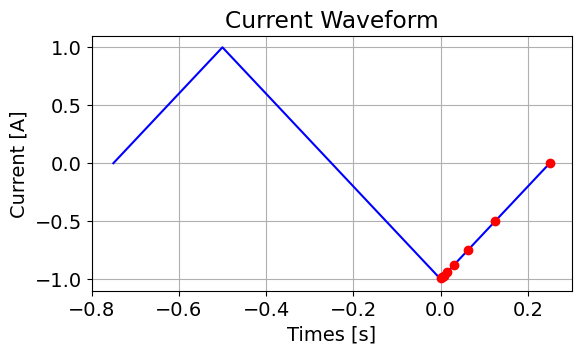

In [7]:
fig = plt.figure(figsize=(6, 3))

ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.85])
plot_times = np.linspace(-0.75 * period, 0.25 * period, 25)
ax1.plot(
    plot_times,
    [utem_waveform.eval(t) for t in plot_times],
    "b"
)
ax1.plot(
    time_channels,
    [utem_waveform.eval(t) for t in time_channels],
    "ro"
)
ax1.grid()
ax1.set_xlabel("Times [s]")
ax1.set_ylabel("Current [A]")
ax1.set_title("Current Waveform")

plt.show()

#### Defining the Source, Receiver and Survey

We use the same approach for generating the survey as was demonstrated in the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial. **For this tutorial,** the db/dt receivers within the borehole measure the fields according to a borehole-centric coordinate system. The borehole-centric coordinate system is defined as follows:
* *Strike direction (U):* which in this case is in the Northing direction
* *Dip direction (V):* which in this case is in the Easting direction
* *Downhole direction (A):* which in this case is in the down direction

```{admonition} Note
:class: note
For real-world problems, boreholes are not perfectly vertical, as resolving near-vertical borehole orientation becomes challenging.
``` 

In [8]:
# Necessary to define transmitter on surface topography
topo_interp = LinearNDInterpolator(np.c_[x_topo, y_topo], z_topo)

In [9]:
# Define the transmitter loop using 50 m segments.
# Necessary to discretize along wire path.
half_width = 0.5 * loop_width
u = np.arange(-half_width, half_width, 50.0)
v = half_width * np.ones_like(u)

xtx = np.r_[u, v, -u, -v, -half_width]
ytx = np.r_[-v, u, v, -u, -half_width]
ztx = topo_interp(np.c_[xtx, ytx])
xyz_loop = np.c_[xtx, ytx, ztx]

In [10]:
# Define the borhole receiver locations
z_bh = np.arange(s_min, s_max+ds, ds)
receiver_locations = ndgrid(x_bh, y_bh, z_bh)

In [11]:
# Define the orientations for the U, V and A receivers
orientations_list = [
    np.r_[0, 1, 0],
    np.r_[1, 0, 0],
    np.r_[0, 0, -1]
]

# Define U, V, A receivers
receivers_list = [
    tdem.receivers.PointMagneticFluxTimeDerivative(
        receiver_locations, time_channels, orientation=orient
    ) for orient in orientations_list
]

# Define the loop source
source_list = [
    tdem.sources.LineCurrent(
        receivers_list, location=xyz_loop, waveform=utem_waveform
    )
]

# Define the survey
survey = tdem.Survey(source_list)

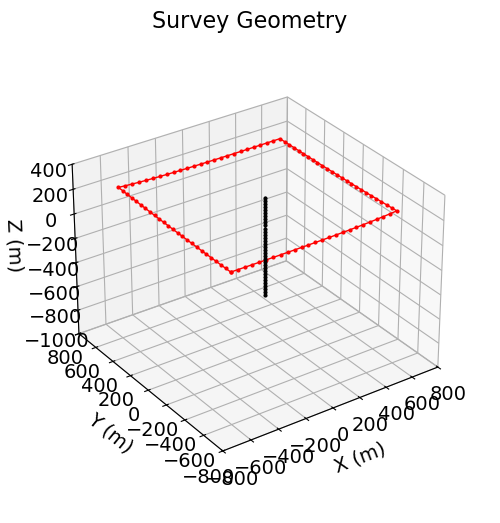

In [12]:
# Plot the survey geometry
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_xlim([-800, 800])
ax.set_ylim([-800, 800])
ax.set_zlim([-1000, 400])
ax.plot(xyz_loop[:, 0], xyz_loop[:, 1], xyz_loop[:, 2], "r-o", lw=1, markersize=2)
ax.plot(
    receiver_locations[:, 0],
    receiver_locations[:, 1],
    receiver_locations[:, 2],
    "k-o",
    lw=1,
    markersize=2
)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Survey Geometry", fontsize=16, pad=-20)
ax.view_init(elev=30.0, azim=-125)

## Defining Maxwell Plates

Maxwell plates are often used to represent rectangular plate conductors. In SimPEG, the properties of a Maxwell plate are stored within a ``MaxwellPlate`` object. **For this tutorial,** we simulate TDEM data for the two interacting rectangular plate conductors defined below. 

In [13]:
# Define Maxwell plate 1
plate_1 = MaxwellPlate(
    name="plate_1",          # plate name
    east=-216.5,             # hinge point (Easting)
    north=0.,                # hinge point (Northing)
    level=-75.,              # hinge point (Elevation)
    dip=30.,                 # dip (degrees)
    dip_direction=90,        # dip direction (CW from Northing)
    plunge=0.,               # plunge (degrees)
    length=500.,             # strike length (m)
    depth_extent=500.,       # dip length (m)
    conductance=1e3,         # conductance (S)
    ribbons=20,              # number of ribbons
)

In [14]:
# Define Maxwell plate 2
plate_2 = MaxwellPlate(
    name="plate_2",          # plate name
    east=-100,               # hinge point (Easting)
    north=-100.,             # hinge point (Northing)
    level=75.,               # hinge point (Elevation)
    dip=20.,                 # dip (degrees)
    dip_direction=45,        # dip direction (CW from Northing)
    plunge=0.,               # plunge (degrees)
    length=300.,             # strike length (m)
    depth_extent=300.,       # dip length (m)
    conductance=1e5,         # conductance (S)
    ribbons=20,              # number of ribbons
)

In [15]:
# Organize plates within a list
plate_list = [plate_1, plate_2]

#### Importing/Exporting Maxwell Plates

SimPEG has utility functions for generating and loading Maxwell PTE files compatible with the EMIT Maxwell program. The ``write_pte_file`` function writes a list of ``MaxwellPlate`` objects into a PTE file. The ``read_pte_file`` function reads the PTE file and outputs a list of ``MaxwellPlate`` objects.

In [16]:
# Write list of Maxwell plates to PTE file
# write_pte_file("my_plates.pte", plate_list)

# Load Maxwell plates from PTE file
# plate_list = read_pte_file("my_plates.pte")

#### Extracting Plate Nodes

We can extract the locations of the nodes defining the Maxwell plate using the `nodes` property. Here, we extract and store the nodes for each Maxwell plate in a list which we will use later.

In [17]:
plate_nodes_list = [p.nodes for p in plate_list]

for p in plate_list:
    print(p.name)
    print(p.nodes)

plate_1
[[-216.5         250.          -75.        ]
 [-216.5        -250.          -75.        ]
 [ 216.51270189 -250.         -325.        ]
 [ 216.51270189  250.         -325.        ]]
plate_2
[[-206.06601718    6.06601718   75.        ]
 [   6.06601718 -206.06601718   75.        ]
 [ 205.40492449   -6.72710986  -27.606043  ]
 [  -6.72710986  205.40492449  -27.606043  ]]


#### Plotting the Maxwell Plates

Below, we plot the problem geometry including the geometry of both Maxwell plates. **Please note** that since we are using the ``matplotlib`` library, changing view angle or the geometry of the plates may not preserve the 3D perspective for overlapping shapes.

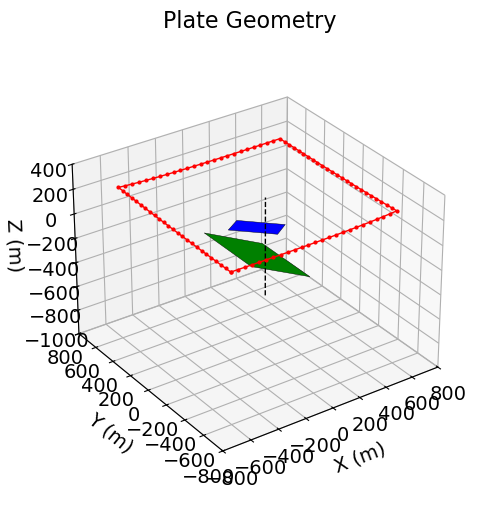

In [18]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_xlim([-800, 800])
ax.set_ylim([-800, 800])
ax.set_zlim([-1000, 400])

for p, c in zip(plate_nodes_list, ['g', 'b']):
    poly_faces = Poly3DCollection(p.reshape((1, 4, 3)))
    poly_faces.set_facecolor(c)
    poly_faces.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
    poly_faces.set_linewidth(0.3)
    poly_faces.set_zorder(1)
    ax.add_collection3d(poly_faces)

ax.plot(
    receiver_locations[:, 0],
    receiver_locations[:, 1],
    receiver_locations[:, 2],
    "k--",
    lw=1,
    zorder=4
)

ax.plot(
    xyz_loop[:, 0],
    xyz_loop[:, 1],
    xyz_loop[:, 2],
    "r-o", lw=1,
    markersize=2,
    zorder=4
)

ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Plate Geometry", fontsize=16, pad=-20)
ax.view_init(elev=30.0, azim=-125)

## Defining a (Tree) Mesh

In the tutorial [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb), we designed our mesh according to the rules of thumb provided in the [Fundamentals of Finite Volume for TDEM Simulations](fwd_tdem_fundamentals.ipynb) tutorial. Discretization throughout the mesh was determined by diffusion distances and proximity to the wire transmitter. These rules still apply since we need to accurately capture the electromagnetic fields related to larger-scale structures throughout the modeling domain.

When designing a mesh to model sheet-like conductors, we must also consider:

1. the smoothness of the primary electromagnetic field over the sheet-like conductor
2. the smoothness of the secondary currents over the sheet-like conductor
3. the smoothness of the secondary electromagnetic fields outside the sheet-like conductor
4. the locations of the receivers relative to the margins of the sheet-like conductor

For an inductive source, the parameterization of a sheet-like conductor onto mesh should preserve the integration of the primary magnetic flux over the surface of the sheet-like conductor. This is easier when the primary magnetic flux over the sheet-like conductor is smooth. If a sheet-like conductor lies in close proximity to an inductive source, finer discretization is required. While firm guidelines have yet to be established, we recommend using a cell size so that the sheet-like conductor is at least 3-4 cells away from the transmitter.

The discretization must also be fine enough to capture the diffusion of induced eddy currents within the sheet-like conductor. For a rectangular plate conductor, we recommend the plate conductor be at least 8-10 cells wide. Finer cells are required for sheet-like structures that are electrically inhomogeneous or have complex shape.

The cell width chosen to discretize about the sheet-like conductor should extend at least 4-6 cells away from the conductor to capture the secondary electromagnetic fields. It is especially important to capture the electromagnetic fields at the edges of sheet-like conductors.

The parameterization of a sheet-like conductor onto a structured (e.g. OcTree) mesh produces large numerical errors close to the sheet-like conductor. Numerical accuracy is generally reasonable when field measurements are at least 3-4 cell widths away from the parameterized sheet-like conductor. 

**Tutorial mesh:** Here, a minimum cell width of 25 m is used in proximity of the transmitter loop to accurately capture the geometry of the primary field. A minimum cell width of 25 m is used near the receivers to minimize interpolation error. And a minimum cell width of 25 m is used in the region where a sheet-like conductor is modeled in order to capture the diffusion of eddy currents and secondary magnetic fields. A discretization of 50 m is used for the remainder of the survey region. The host has a conductivity of 1e-3 S/m. Since the diffusion distance for the host is so large at the earliest time channel, the cell size within the survey region is more driven by geometry of the primary field. The largest diffusion distance is ~20,000 m. So the width of the padding region was set to 40,000 m in all directions.

In [19]:
air_conductivity = 1e-8
host_conductivity = 1e-3

In [20]:
host_diffusion_distance = 1260 * np.sqrt(time_channels / host_conductivity)
print("HOST: {}".format(host_diffusion_distance))

HOST: [ 1760.90353228  2490.29365738  3521.80706456  4980.58731477
  7043.61412912  9961.17462953 14087.22825825 19922.34925906]


In [21]:
# Instantiate OcTree mesh
dh = 25.0
L = 80000.0
nbc = 2 ** int(np.round(np.log(L / dh) / np.log(2.0)))
h = [(dh, nbc)]
mesh = TreeMesh([h, h, h], origin="CCC", diagonal_balance=True)

# Shift vertically so top same as maximum topography
mesh.origin += np.r_[0.0, 0.0, z_topo.min()]

In [22]:
# Discretize around transmitter
n_seg = np.shape(xyz_loop)[0] - 1
n_pts_per_seg = 20

pts = [
    np.c_[
        np.linspace(xyz_loop[ii, 0], xyz_loop[ii + 1, 0], n_pts_per_seg),
        np.linspace(xyz_loop[ii, 1], xyz_loop[ii + 1, 1], n_pts_per_seg),
        np.linspace(xyz_loop[ii, 2], xyz_loop[ii + 1, 2], n_pts_per_seg),
    ]
    for ii in range(n_seg)
]

pts = np.vstack(pts)
mesh.refine_points(pts, level=-1, padding_cells_by_level=[4, 3, 2, 2], finalize=False)

In [23]:
# Discretize around borehole receivers
mesh.refine_points(receiver_locations, level=-1, padding_cells_by_level=[3, 3], finalize=False)

In [24]:
# Discretization for core survey region
pts = ndgrid(
    np.r_[-700, 700], np.r_[-700, 700], np.r_[z_topo.min() - 800, z_topo.min() + 50]
)

mesh.refine_bounding_box(pts, -2, padding_cells_by_level=[0, 4, 4], finalize=False)

In [25]:
# Discretize surface topography
inds = (np.abs(topo_xyz[:, 0]) < 1400.0) & (np.abs(topo_xyz[:, 1]) < 1400.0)

mesh.refine_surface(
    topo_xyz[inds, :], -2, padding_cells_by_level=[1, 2], finalize=False
)

In [26]:
# Discretize in the region of the sheet-like conductor
pts = ndgrid(
    np.r_[-300, 300], np.r_[-300, 300], np.r_[-400, 150]
)

mesh.refine_bounding_box(pts, -1, padding_cells_by_level=[0, 4, 4], finalize=False)

In [27]:
mesh.finalize()

In [28]:
print(f"MESH CELLS: {mesh.n_cells}")

MESH CELLS: 81880


## Defining the Background Conductivity

Here, we define the cell conductivities that parameterize all large-scale less conductive structures within the modeling domain. By adopting the term 'background conductivity', we are stating that the cell conductivities are fixed parameters in the forward simulation. Our model (defined later) therefore consists of the parameters defining a sheet-like conductor. **For this tutorial,** all cells below the discrete surface topography are assigned a conductivity of 1e-3 S/m and all air cells are assigned a conductivity of 1e-8 S/m. So, the background conductivity is an (n_cells,) [numpy.ndarray](xref:numpy#numpy.ndarray).

```{admonition} Complex background conductivity
:class: note
The hierarchical finite volume approach allows complete freedom to include 3D structure in the background conductivity. We are not limited to a homogeneous background.
```

```{admonition} Including conductivity in the model
:class: note
Cell conductivities can be included in the model but implementation becomes more complicated. The model would contain two parameter types and the user would need to construct a appropriate mappings for multiple hierarchical electrical properties.
```

In [29]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = active_from_xyz(mesh, topo_xyz)

# Define the background conductivity (n_cells,)
background_conductivity = air_conductivity * np.ones(mesh.n_cells)
background_conductivity[active_cells] = host_conductivity

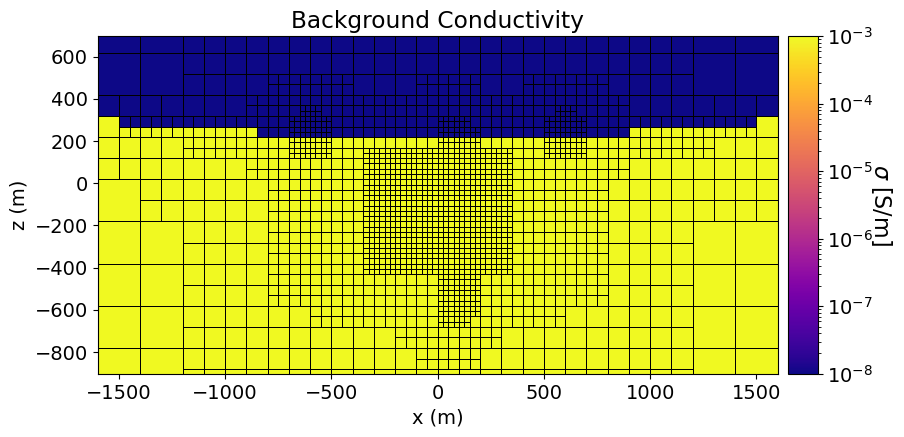

In [30]:
# Plot the background conductivity
fig = plt.figure(figsize=(10, 4.5))

norm = LogNorm(vmin=background_conductivity.min(), vmax=background_conductivity.max())

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
mesh.plot_slice(
    background_conductivity,
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
    grid_opts={"lw": 0.5, "color": 'k'}
)
ax1.set_title("Background Conductivity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax1.set_xlim([-1600, 1600])
ax1.set_ylim([z_topo.max() - 1200, z_topo.max() + 400])

ax2 = fig.add_axes([0.84, 0.15, 0.03, 0.75])
cbar = mpl.colorbar.ColorbarBase(
    ax2, cmap=mpl.cm.plasma, norm=norm, orientation="vertical"
)
cbar.set_label(r"$\sigma$ [S/m]", rotation=270, labelpad=15, size=16)

## Projecting Maxwell Plates onto Meshes

The hierarchical finite volume approach simulates TDEM fields by representing sheet-like conductors as conductances that live on mesh faces. Our Maxwell plates must therefore be mapped onto the faces of the OcTree mesh. We do this by determining the set of mesh faces that best approximates the geometry of each plate, and we assign the corresponding conductance value (e.g. 1000 S) to those faces. All other faces are assigned a parameter value of 0.

#### Finding the mesh faces

Earlier, we generate a list containing the node locations for each of our Maxwell plates. For each set of nodes, we can use the ``get_face_indices_plate`` utility to obtain the indices of the mesh faces that best represent the corresponding plate. ``get_face_indices_plate`` inputs the `mesh` and a (4, 3) [numpy.ndarray](xref:numpy#numpy.ndarray) representing the 4 node locations of the plate. It outputs an (n_faces,) boolean array where `True` values represent faces that are used to parameterize the plate.

In [31]:
# Find the face indices for each plate on the mesh
face_inds_list = [get_face_indices_plate(mesh, p) for p in plate_nodes_list]

Below, we plot the true geometry of plate 1 and the set of mesh faces that approximate its geometry. As we can see, this results in a staircase-like structure for OcTree meshes.

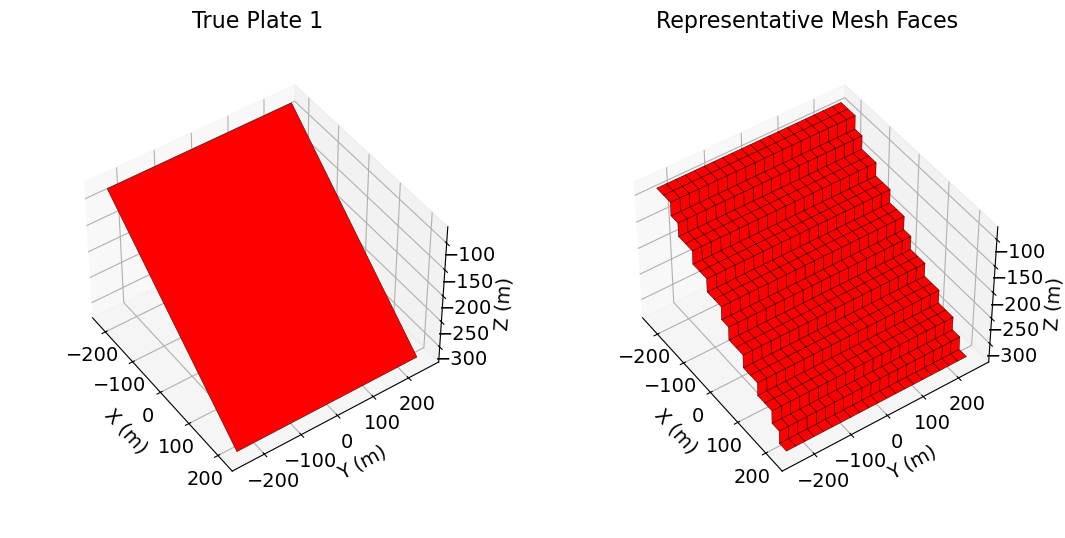

In [32]:
plate_faces = mesh.faces[face_inds_list[0], :]
plate_normals = mesh.face_normals[face_inds_list[0], :]
n_plate_faces = sum(plate_faces)

poly_pts = np.expand_dims(plate_faces, axis=1)
poly_pts = np.tile(poly_pts, (1, 4, 1))
for ii, nrml in enumerate(plate_normals):
    if nrml[0] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [0, -1, -1], [0, 1, -1], [0, 1, 1], [0, -1, 1]
        ])
    elif nrml[1] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [-1, 0, -1], [1, 0, -1], [1, 0, 1], [-1, 0, 1]
        ])
    elif nrml[2] == 1.:
        poly_pts[ii, :, :] += dh/2 * np.array([
            [-1, -1, 0], [1, -1, 0], [1, 1, 0], [-1, 1, 0]
        ])

fig = plt.figure(figsize=(11, 6))
ax1 = fig.add_axes([0.0, 0.1, 0.45, 0.85], projection="3d")
ax2 = fig.add_axes([0.5, 0.1, 0.45, 0.85], projection="3d")

poly_faces = Poly3DCollection(plate_nodes_list[0].reshape((1, 4, 3)))
poly_faces.set_facecolor('r')
poly_faces.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_faces.set_linewidth(0.3)
ax1.add_collection3d(poly_faces)
ax1.set_box_aspect(aspect=None, zoom=0.8)
ax1.set_xlabel("X (m)", labelpad=10)
ax1.set_ylabel("Y (m)", labelpad=10)
ax1.set_zlabel("Z (m)", labelpad=10)
ax1.set_title("True Plate 1", fontsize=16, pad=-20)
ax1.view_init(elev=45.0, azim=-35)
             
poly_faces = Poly3DCollection(poly_pts)
poly_faces.set_facecolor('r')
poly_faces.set_edgecolor('black')  # Set to 'none' if you want a smooth look without wireframes
poly_faces.set_linewidth(0.3)
ax2.add_collection3d(poly_faces)
ax2.set_box_aspect(aspect=None, zoom=0.8)
ax2.set_xlabel("X (m)", labelpad=10)
ax2.set_ylabel("Y (m)", labelpad=10)
ax2.set_zlabel("Z (m)", labelpad=10)
ax2.set_title("Representative Mesh Faces", fontsize=16, pad=-20)
ax2.view_init(elev=45.0, azim=-35)

plt.show()

#### Defining the Face Conductances Model

SimPEG requires that we define a model to input into the simulation. Here, the model parameters are the face conductances for each face in the mesh. So the number of model parameters is equal to the number of mesh faces. We construct the model by first defining a [numpy.ndarray](xref:numpy#numpy.ndarray) of zeros. Then for each plate, we assign the conductance value to all indexed faces.

```{admonition} Multiple plates
:class: note
For each plate, just find the representative faces and replace the values in the model vector. Face conductance values will be overwritten if plates intersect.
```

In [33]:
# Instantiate as a (n_faces,) vector of zeros
face_conductance_model = np.zeros(mesh.n_faces)

# Assign plate conductance to all representative faces
for ind, p in zip(face_inds_list, plate_list):
    face_conductance_model[ind] = p.conductance

#### Defining the Mapping

SimPEG requires that we define a mapping between the set of model parameters to all mesh faces. Since the model parameters are the conductances for all mesh faces, we use the [simpeg.maps.IdentityMap](xref:simpeg#simpeg.maps.IdentityMap) class. **However,** we must make sure to manually set the number of parameters *nP* to equal the number of mesh faces!!!

In [34]:
plate_conductance_map = maps.IdentityMap(nP=mesh.n_faces)

## Defining the Time-Stepping

Here, we define the time-stepping that is used for the forward simulation. We reuse the time-stepping from the [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb). The resulting time-steps are illustrated below.

In [35]:
# Minimum time step based on earliest time channel
n_steps = 20
min_dt = time_channels[0] / 20.0
min_dt = round(min_dt, 1 - int(np.floor(np.log10(min_dt))) - 1)

# Find times where step length is increased
tc_min = np.min(time_channels)
tc_max = np.max(time_channels)
ti = [None, tc_min, 6 * tc_min, 36 * tc_min]
dt = [period / 60, min_dt, 6 * min_dt, 36 * min_dt]

In [36]:
# Define all discrete times
wave_times = np.arange(-0.75 * period, 0, dt[0])
wave_times = np.r_[wave_times, np.arange(0, ti[1] + dt[1], dt[1])]
wave_times = np.r_[wave_times, np.arange(wave_times[-1] + dt[2], ti[2] + dt[2], dt[2])]
wave_times = np.r_[wave_times, np.arange(wave_times[-1] + dt[3], ti[3] + dt[3], dt[3])]
wave_times = np.r_[
    wave_times, np.arange(wave_times[-1] + dt[0], tc_max + 2 * dt[0], dt[0])
]

In [37]:
# Take difference to obtain time steps
time_steps = np.diff(wave_times)

# Initial time for the simulation
t0 = wave_times[0]

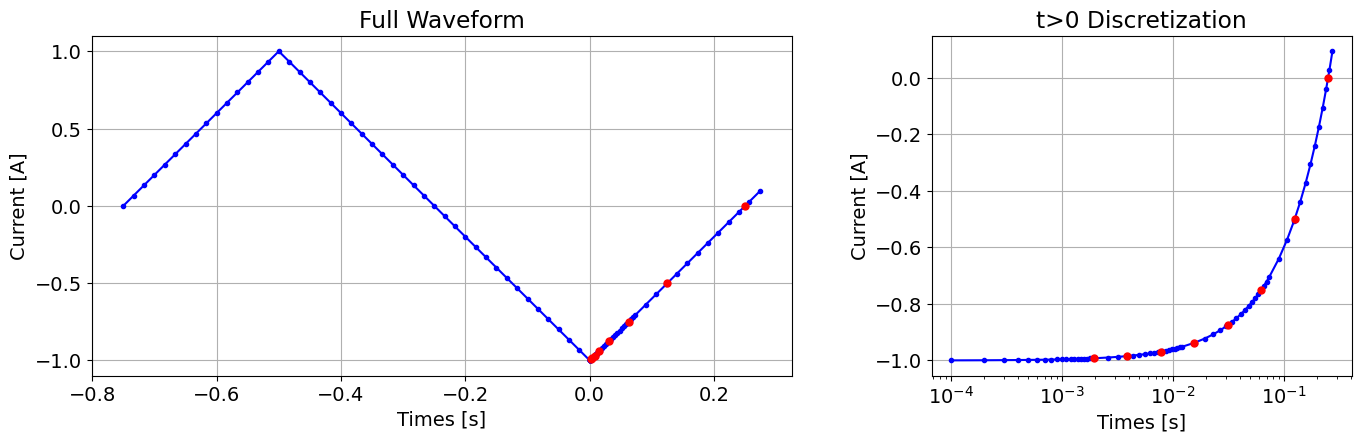

In [38]:
fig = plt.figure(figsize=(14, 4))

ax1 = fig.add_axes([0.1, 0.1, 0.5, 0.85])
ax1.plot(
    wave_times,
    [utem_waveform.eval(t) for t in wave_times],
    "b-o",
    markersize=3
)
ax1.plot(
    time_channels,
    [utem_waveform.eval(t) for t in time_channels],
    "ro",
    markersize=5
)
ax1.grid()
ax1.set_xlabel("Times [s]")
ax1.set_ylabel("Current [A]")
ax1.set_title("Full Waveform")

ax2 = fig.add_axes([0.7, 0.1, 0.3, 0.85])
plot_times = np.logspace(np.log10(time_channels.min()), np.log10(time_channels.max()))
k = wave_times > 0.0
ax2.semilogx(
    wave_times[k],
    [utem_waveform.eval(t) for t in wave_times[k]],
    "b-o",
    markersize=3
)
ax2.semilogx(
    time_channels,
    [utem_waveform.eval(t) for t in time_channels],
    "ro",
    markersize=5
)
ax2.grid()
ax2.set_xlabel("Times [s]")
ax2.set_ylabel("Current [A]")
ax2.set_title("t>0 Discretization")

plt.show()

## Simulating the Data

#### Defining the Simulation

For hierarchical electrical properties, we cannot use the standard 3D TDEM simulation classes. We must use one of the following classes:

* [Simulation3DHierarchicalElectricField](xref:simpeg#simpeg.electromagnetics.time_domain.simulation.Simulation3DHierarchicalElectricField), which solves for the electric fields on mesh edges.
* [Simulation3DHierarchicalMagneticFlux](xref:simpeg#simpeg.electromagnetics.time_domain.simulation.Simulation3DHierarchicalMagneticFlux), which solves for the magnetic flux densities on mesh faces.

Since the source is a line current and the receivers are measuring db/dt, we will use the electric field formulation. Hierarchical simulation classes allow the user to fix any of the hierarchical properties in the forward simulation or include them in the model. Relevant kwargs when instiating a hierarchical simulation object are as follows:

* `sigma` or `sigmaMap`: Use `sigma` to set and fix the cell conductivity values in the forward simulation. Use `sigmaMap` to define the mapping if parameters related to cell conductivities are included in the model.
* `face_conductance` or `face_conductance_map`: Use `face_conductance` to set and fix the face conductance values in the forward simulation. Use `face_conductance_map` to define the mapping if parameters related to face conductances are included in the model.
* `edge_integrated_conductance` or `edge_integrated_conductance_map`: Use `edge_integrated_conductance` to set and fix the edge integrated conductance values in the forward simulation. Use `edge_integrated_conductance_map` to define the mapping if parameters related to edge integrated conductances are included in the model.

**For the tutorial,** we use `sigma` to set and fix the cell conductivities to the values for our background conductivity. Our model parameters are the face conductances for all mesh faces, so we use `face_conductance_map` to set the mapping. Since wire-like structures are not considered, we do not set `edge_integrated_conductance` or `edge_integrated_conductance_map`.

In [39]:
simulation_plate = tdem.simulation.Simulation3DHierarchicalElectricField(
    mesh,
    survey=survey,
    sigma=background_conductivity,
    face_conductance_map=plate_conductance_map,
    solver=get_default_solver()
)
simulation_plate.time_steps = time_steps
simulation_plate.t0 = t0

#### Predicting the Data

In [40]:
dpred_plate = simulation_plate.dpred(face_conductance_model)

## Plotting Primary Reduced Data

Here, we plot the primary reduced representation of the predicted data. Our method for generating primary reduced data is explained in the  [3D Forward Simulation for On-Time Large-Loop Data](fwd_utem_3d.ipynb) tutorial.

#### Generating Numerical Primary Field Data

We currently have total field data that were collected during the transmitter's on-time. Here, we compute a numerical primary field that can be subtracted to obtain secondary field data.

In [41]:
# Define a vacuum background conductivity
vacuum_conductivity = air_conductivity * np.ones_like(background_conductivity)

# Replace the background conductivity in the simulation
simulation_plate.sigma = vacuum_conductivity

# For the vacuum model, all parameter values are 0
vacuum_model = np.zeros(mesh.n_faces)

# Simulate the fields
dpred_0 = simulation_plate.dpred(vacuum_model)

#### Generating Primary Reduced Data

In [42]:
# Reshape predicted data vectors to arrays and convert to b-field representation
n_comp = 3  # Simulated x, y and z components
n_rx = np.shape(receiver_locations)[0]  # number of receiver locations
n_times = len(time_channels)  # number of time channels

b_plate = (period / 4) * np.reshape(dpred_plate, (n_comp, n_times, n_rx))
b_0 = (period / 4) * np.reshape(dpred_0, (n_comp, n_times, n_rx))

In [43]:
# Compute the absolute value of the primary b-field
b_p = computeH0(xyz_loop, receiver_locations)  # list with x, y and z component
b_p = mu_0 * np.sqrt(b_p[0]**2 + b_p[1]**2 + b_p[2]**2)

In [44]:
# Compute primary reduced data for U, V and A directions
u_plate = 100 * (b_plate[0, :, :] - b_0[0, :, :]) / b_p
v_plate = 100 * (b_plate[1, :, :] - b_0[1, :, :]) / b_p
a_plate = 100 * (b_plate[2, :, :] - b_0[2, :, :]) / b_p

data_plate = [u_plate, v_plate, a_plate]

#### Plotting Primary Reduced Data

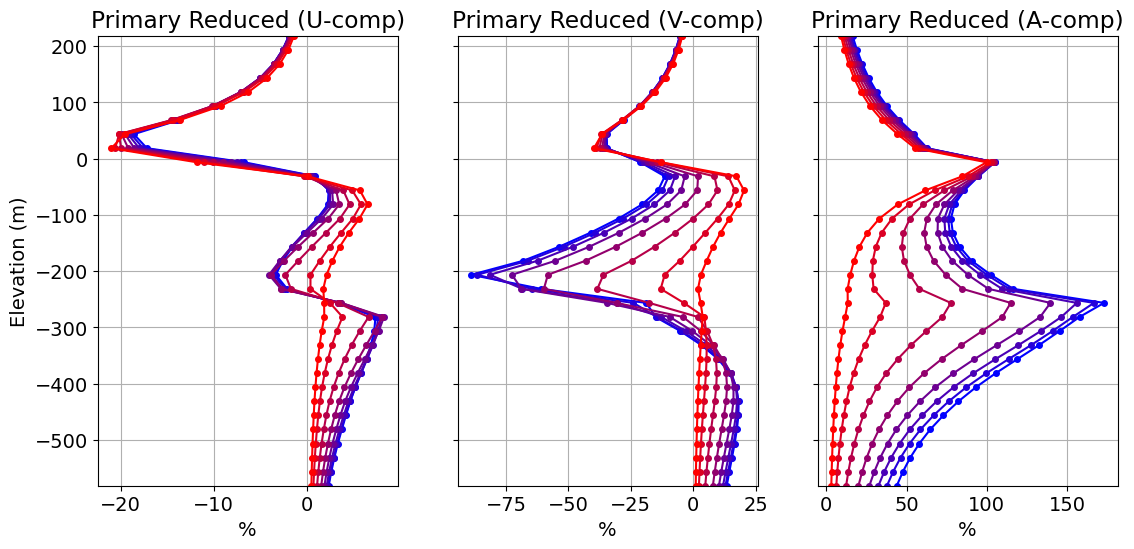

In [45]:
fig = plt.figure(figsize=(12, 6))
ax1 = [fig.add_axes([0.05 + 0.3 * ii, 0.2, 0.25, 0.75]) for ii in range(0, 3)]

comp_list = ["U", "V", "A"]

for ii in range(0, 3):
    d_temp = data_plate[ii]

    for jj in range(n_times):
        ax1[ii].plot(
            d_temp[jj, :],
            receiver_locations[:, 2],
            marker="o",
            color=[jj / (n_times - 1), 0, 1 - jj / (n_times - 1)],
            markersize=4,
            label="_nolegend_",
        )

    ax1[ii].grid()
    ax1[ii].ticklabel_format(axis="both", scilimits=(0, 3))
    ax1[ii].set_xlabel("%")
    ax1[ii].set_ylim([s_min, s_max])
    if ii == 0:
        ax1[ii].set_ylabel("Elevation (m)")
    else:
        ax1[ii].set_yticklabels([])
    ax1[ii].set_title("Primary Reduced ({}-comp)".format(comp_list[ii]))

plt.show(fig)